In [51]:
from pathlib import Path

import arviz as az
import arviz_plots as azplt
import arviz.preview as azp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc_bart as pmb

from sklearn.model_selection import train_test_split

# Bokeh plotting library and functions. Note, this is probably an overkill but I have used most of these in my other projects.
from bokeh.io import output_notebook, show
from bokeh.models.annotations.labels import Label
from bokeh.layouts import column, row
from bokeh.models import ColumnDataSource, CustomJS, Slider, Whisker, BoxAnnotation, Arrow, OpenHead, Span
from bokeh.plotting import figure, show, output_file, save
from bokeh.models import Legend, LinearAxis, Range1d, ColumnDataSource, LabelSet, HoverTool, DatetimeTickFormatter

%config InlineBackend.figure_format = "retina"

print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v5.27.1


In [57]:
RANDOM_SEED = 5781
np.random.seed(RANDOM_SEED)
az.style.use("arviz-whitegrid")

In [6]:
try:
    coal = np.loadtxt(Path("..", "data", "coal.csv"))
except FileNotFoundError:
    coal = np.loadtxt(pm.get_data("coal.csv"))

In [7]:
# discretize data
years = int(coal.max() - coal.min())
bins = years // 4
hist, x_edges = np.histogram(coal, bins=bins)
# compute the location of the centers of the discretized data
x_centers = x_edges[:-1] + (x_edges[1] - x_edges[0]) / 2
# xdata needs to be 2D for BART
x_data = x_centers[:, None]
# express data as the rate number of disaster per year
y_data = hist

In [8]:
with pm.Model() as model_coal:
    μ_ = pmb.BART("μ_", X=x_data, Y=np.log(y_data), m=20)
    μ = pm.Deterministic("μ", pm.math.exp(μ_))
    y_pred = pm.Poisson("y_pred", mu=μ, observed=y_data)
    idata_coal = pm.sample(random_seed=RANDOM_SEED)

Multiprocess sampling (4 chains in 4 jobs)
PGBART: [μ_]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 88 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


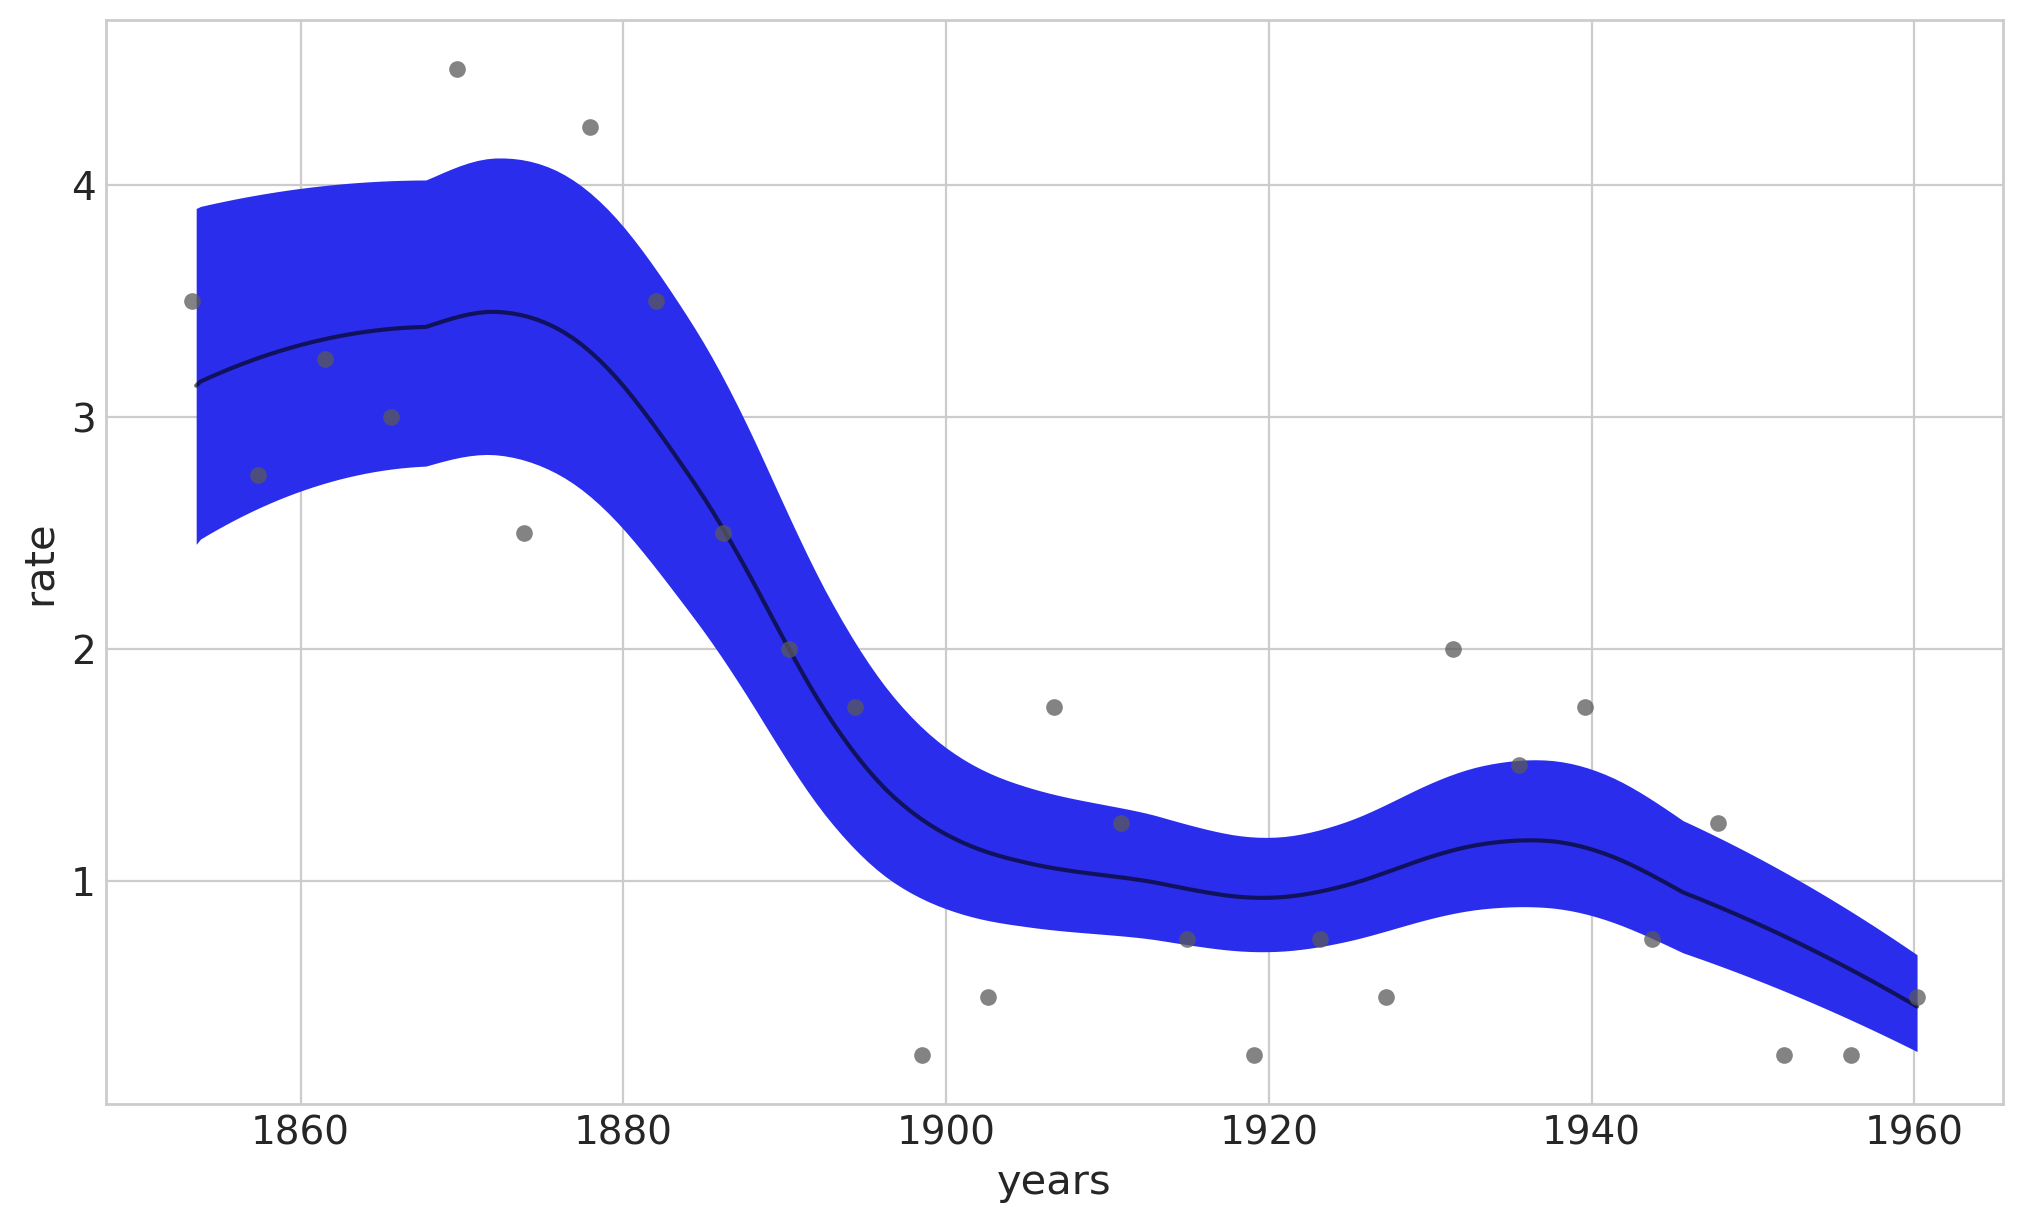

In [24]:
rates = idata_coal.posterior["μ"] / 4

# 1) Build an InferenceData using ArviZ (not arviz_plots)
idata_plot = az.from_dict(
    posterior={"rate": rates},
    observed_data={"rate": y_data / 4},
    constant_data={"years": x_centers},
    dims={"rate": ["x_dim_0"], "years": ["x_dim_0"]},
)

# 2) Convert to DataTree for arviz-plots
dt_plot = az.to_datatree(idata_plot)

azplt.plot_lm(
    dt_plot,
    x="years",
    y="rate",
    y_obs="rate",
    group="posterior",
    visuals={"observed_scatter": {"alpha": 0.75}},
    figure_kwargs={"figsize": (10, 6)},
);

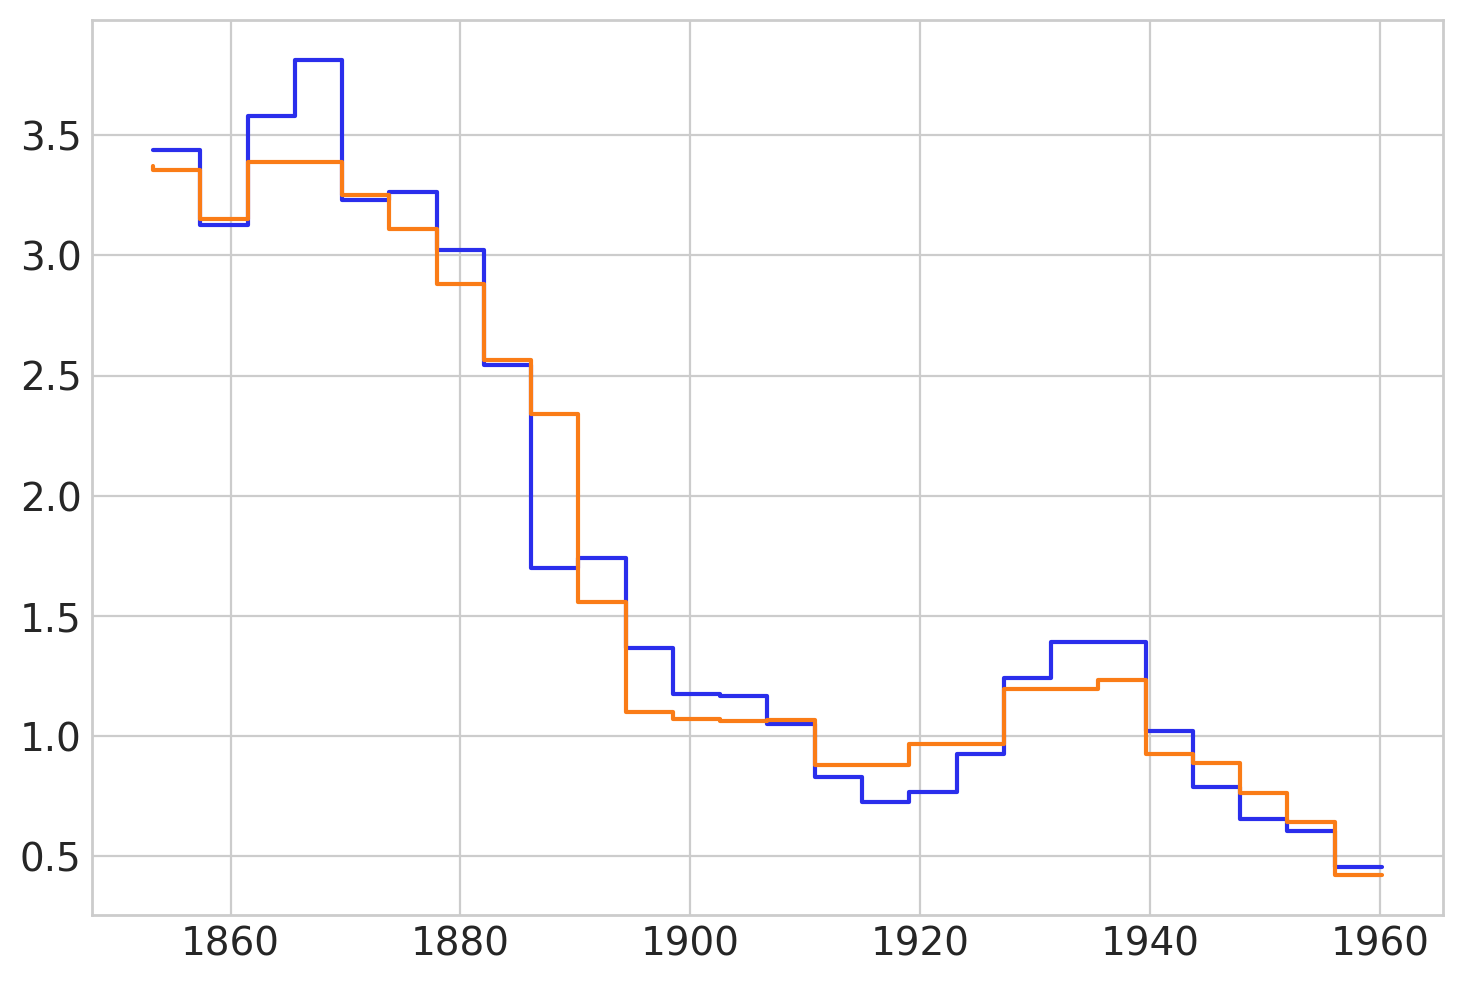

In [26]:
plt.step(x_data, rates.sel(chain=0, draw=[3, 10]).T);